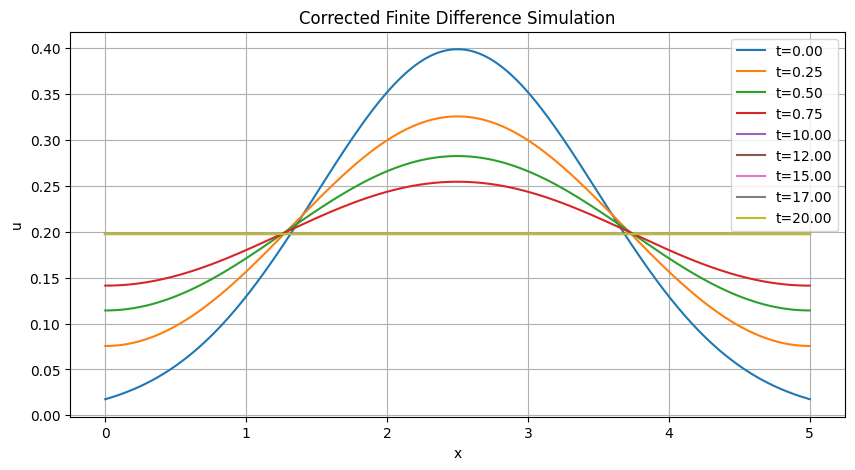

In [ ]:
#finite difference method for diffussion equation

import numpy as np

import matplotlib.pyplot as plt
def f(x):
  sigma=1
  x0=2.5
  return (np.exp(-(x-x0)**2/(2*sigma**2)))/(sigma*(2*(np.pi))**(0.5))

def finite_diff(x_p,nx,L):


  dx=L/(nx-1)
  D=1
  t=20
  dt=0.4*(dx**2)/D
  nt=int(t/dt)
  u=np.zeros((nx,nt))
  u[:,0]=f(x_p)
  for l in range(nt-1):


    u[1:-1,l+1]=u[1:-1,l]+((D*dt)/dx**2)*(u[:-2,l]-2*u[1:-1,l]+u[2:,l])
    u[0,l+1]=u[1,l+1]
    u[-1,l+1]=u[-2,l+1]

  return u,nt,dt
L=5
nx=600
x_p=np.linspace(0, L, nx)
u_exp, nt_exp, dt_exp = finite_diff(x_p, nx, L)
snapshots = [0, 0.25, 0.5, 0.75, 10, 12, 15, 17, 20]
plt.figure(figsize=(10,5))
for t_val in snapshots:
    time_idx=int(t_val / dt_exp)
    if time_idx >= nt_exp:
        time_idx=nt_exp-1
    plt.plot(x_p, u_exp[:,time_idx],label=f't={t_val:.2f}')

plt.xlabel("x")
plt.ylabel("u")
plt.title("Corrected Finite Difference Simulation")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
print('hi')

hi


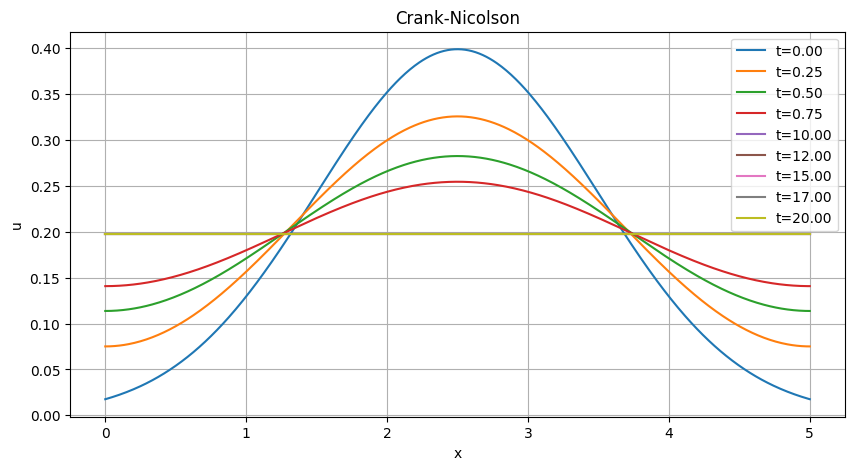

In [1]:
# Crank-Nicolson
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import solve_banded

def f(x):
  sigma=1
  x0=2.5
  return (np.exp(-(x-x0)**2/(2*sigma**2)))/(sigma*(2*(np.pi))**(0.5))

def finite_diff_cn(x_p, nx, L):
  dx=L/(nx - 1)
  D=1
  t=20
  dt=0.4*(dx**2)/D
  nt=int(t/dt)

  r=D*dt/(2*dx**2)
  ab = np.zeros((3, nx))

  ab[0, 1:]  = -r              # upper diagonal
  ab[1, :]   = 1 + 2*r         # main diagonal
  ab[2, :-1] = -r              # lower diagonal
  ab[0,1]=-2*r
  ab[2,-2]=-2*r
  u = np.zeros((nx, nt))
  u[:, 0] = f(x_p)

  for l in range(nt - 1):
      rhs=np.zeros(nx)

      rhs[1:-1] = r*u[:-2,l] + (1 - 2*r)*u[1:-1,l] + r*u[2:,l]
      rhs[0]=(1-2*r)*u[0,l]+2*r*u[1,l]
      rhs[-1]=2*r*u[-2,l]+(1-2*r)*u[-1,l]
      u[:, l+1] = solve_banded((1,1), ab, rhs)


  return u, nt, dt

L = 5
nx = 600
x_p = np.linspace(0, L, nx)
u_cn,  nt_cn,  dt_cn  = finite_diff_cn(x_p, nx, L)
snapshots = [0, 0.25, 0.5, 0.75, 10, 12, 15, 17, 20]
plt.figure(figsize=(10,5))
for t_val in snapshots:
    time_idx=int(t_val / dt_cn)
    if time_idx >= nt_cn:
        time_idx=nt_cn-1
    plt.plot(x_p, u_cn[:,time_idx],label=f't={t_val:.2f}')

plt.xlabel("x")
plt.ylabel("u")
plt.title("Crank-Nicolson")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# implementing PINN using pytorch for solving  diffusion equation
import torch
import torch.nn as nn

class Pinn_d(nn.Module):
  def __init__(self):
    super(Pinn_d,self).__init__()
    self.net=nn.Sequential(
        nn.Linear(2,32),
        nn.Tanh(),
        nn.Linear(32,32),
        nn.Tanh(),
        nn.Linear(32,1)
    )
  def forward(self,x,t):
    inputs= torch.cat([x,t],dim=1)
    return self.net(inputs)
  def physics_loss(self,x,t):
    D=1.0
    t=t.clone().requires_grad_(True)
    x=x.clone().requires_grad_(True)
    u_pred=self(x,t)
    u_x=torch.autograd.grad(u_pred,x,grad_outputs=torch.ones_like(u_pred),create_graph=True)[0]
    u_t=torch.autograd.grad(u_pred,t,grad_outputs=torch.ones_like(u_pred),create_graph=True)[0]
    u_xx=torch.autograd.grad(u_x,x,grad_outputs=torch.ones_like(u_x),create_graph=True)[0]

    res=u_t-D*u_xx
    return torch.mean( res**2)

  def IC_loss(self,x):
    sigma=1
    x0=2.5
    t_zeros=torch.zeros_like(x)
    u_pred=self(x,t_zeros)
    #Gaussian boundary condition
    f=(torch.exp(-(x-x0)**2/(2*sigma**2)))/(sigma*(2*torch.tensor(torch.pi))**(0.5))
    return torch.mean((u_pred-f)**2)



  def train_model(self,epochs,lr,x_p,t_p,x_b,x_b2):
    optimizer=torch.optim.Adam(self.parameters(),lr)
    prv_loss=0
    loss_history=[]

    for epoch in range(epochs):
      optimizer.zero_grad()

      x_b_rep=x_b.expand(t_p.shape[0],1).clone().requires_grad_(True)
      x_b2_rep=x_b2.expand(t_p.shape[0],1).clone().requires_grad_(True)

      u_b=self(x_b_rep,t_p)
      u_b2=self(x_b2_rep,t_p)
      bc_loss=torch.autograd.grad(u_b,x_b_rep,grad_outputs=torch.ones_like(u_b),create_graph=True)[0]
      boundary_loss=torch.mean(bc_loss**2)
      b_loss2= torch.autograd.grad(u_b2,x_b2_rep,grad_outputs=torch.ones_like(u_b2),create_graph=True)[0]
      boundary_loss2=torch.mean(b_loss2**2)

      Loss=(2*self.physics_loss(x_p,t_p)+5*boundary_loss+5*boundary_loss2+2*self.IC_loss(x_p))

      Loss.backward()
      optimizer.step()
      loss_history.append(Loss.item())

      curr_loss=Loss.item()
      if epoch % 100 == 0:
        if epoch>0:
          diff_loss=curr_loss-prv_loss
          print(f"Epoch {epoch:4d}:Loss {Loss.item():.6f}|differnce in loss {diff_loss:.6f}")
        else:
          print(f"Epoch {epoch:4d}: Loss {Loss.item():.6f}| no previous loss")
      prv_loss=curr_loss
    return loss_history

Epoch    0: Loss 0.059110| no previous loss
Epoch  100:Loss 0.008395|differnce in loss -0.000084
Epoch  200:Loss 0.004354|differnce in loss -0.000024
Epoch  300:Loss 0.002507|differnce in loss -0.000014
Epoch  400:Loss 0.001636|differnce in loss -0.000006
Epoch  500:Loss 0.001217|differnce in loss -0.000006
Epoch  600:Loss 0.000975|differnce in loss 0.000005
Epoch  700:Loss 0.000787|differnce in loss -0.000002
Epoch  800:Loss 0.000657|differnce in loss -0.000002
Epoch  900:Loss 0.000551|differnce in loss -0.000001
Epoch 1000:Loss 0.000478|differnce in loss -0.000000
Epoch 1100:Loss 0.000419|differnce in loss -0.000001
Epoch 1200:Loss 0.000375|differnce in loss -0.000001
Epoch 1300:Loss 0.000336|differnce in loss -0.000000
Epoch 1400:Loss 0.000305|differnce in loss -0.000001
Epoch 1500:Loss 0.000275|differnce in loss -0.000000
Epoch 1600:Loss 0.000251|differnce in loss -0.000094
Epoch 1700:Loss 0.000227|differnce in loss -0.000000
Epoch 1800:Loss 0.000205|differnce in loss -0.000000
Epo

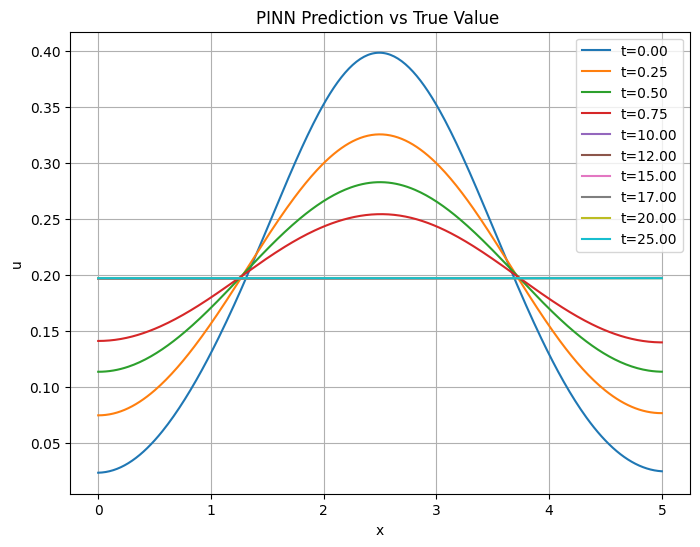

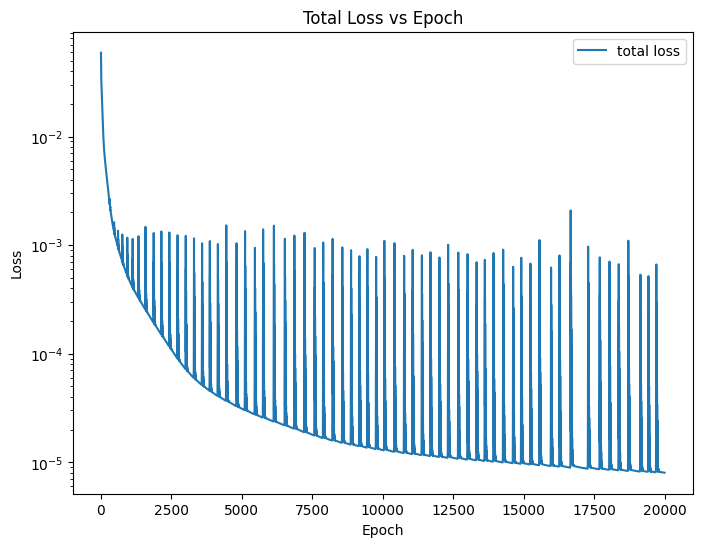

In [ ]:

#plotting
import numpy as np
import matplotlib.pyplot as plt
#  Define training points


x_pnp=np.random.rand(25000,1)*5
t_pnp=np.random.rand(25000,1)*25
x_bnp = np.array([[0.0]])
#y_bnp = np.array([[-1.0]])
x_b2np=np.array([[5.0]])
#y_b2np=np.array([[-1.0]])
model=Pinn_d()
x_p=torch.tensor(x_pnp,dtype=torch.float32)
t_p=torch.tensor(t_pnp,dtype=torch.float32)
x_b=torch.tensor(x_bnp,dtype=torch.float32)
#y_b=torch.tensor(y_bnp,dtype=torch.float32)
x_b2=torch.tensor(x_b2np,dtype=torch.float32)
#y_b2=torch.tensor(y_b2np,dtype=torch.float32)



loss_history=model.train_model(20000,0.001,x_p,t_p, x_b,x_b2)
x_plot_np=np.linspace(0,5,300).reshape(-1,1)
x_plot=torch.tensor(x_plot_np,dtype=torch.float32)
snapshot=[0, 0.25, 0.5, 0.75, 10, 12, 15, 17, 20,25]
plt.figure(figsize=(8, 6))

for t_val in snapshot:
  t_=torch.full_like(x_plot,t_val)
  with torch.no_grad():
    u_pred=model(x_plot,t_).numpy()
  plt.plot(x_plot_np, u_pred, label=f't={t_val:.2f}')
  plt.xlabel("x")
  plt.ylabel("u")
  plt.grid(True)
  plt.title(r"PINN Prediction vs True Value ")
  plt.legend()
plt.figure(figsize=(8, 6))
plt.plot(loss_history, label='total loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.yscale('log')
plt.title('Total Loss vs Epoch')
plt.legend()
plt.show()

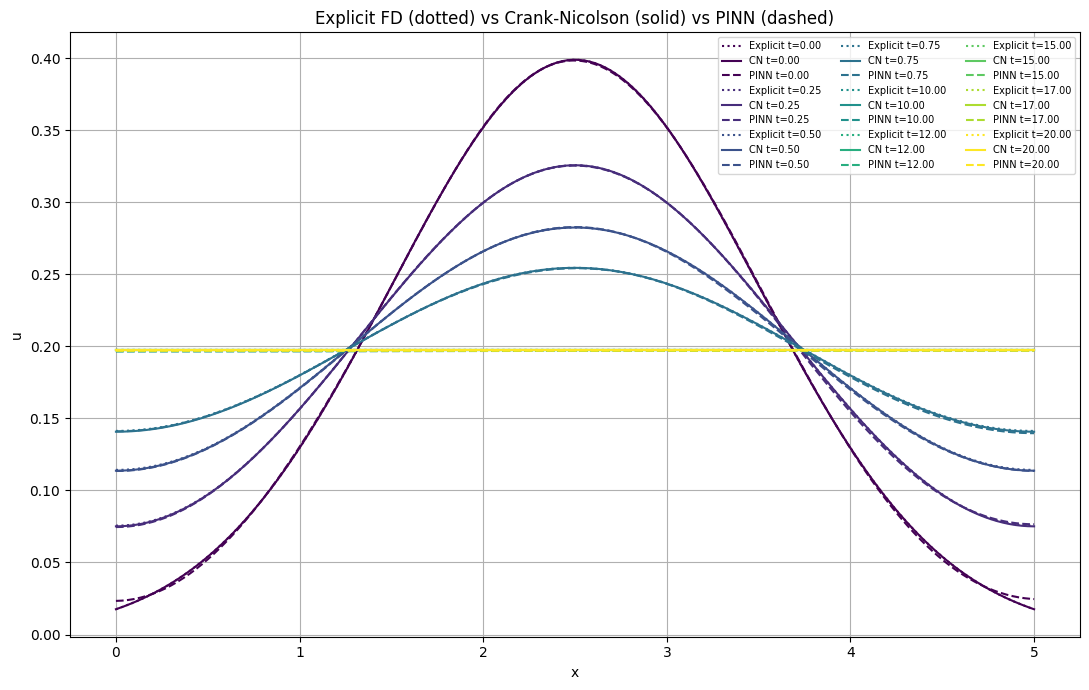

In [ ]:
snapshots = [0, 0.25, 0.5, 0.75, 10, 12, 15, 17, 20]
colors = plt.cm.viridis(np.linspace(0, 1, len(snapshots)))

x_fd = np.linspace(0, L, nx)   # rebuild — x_p was overwritten by the PINN's tensor

plt.figure(figsize=(11, 7))
for t_val, c in zip(snapshots, colors):
    idx_exp = min(int(t_val / dt_exp), nt_exp - 1)
    idx_cn  = min(int(t_val / dt_cn), nt_cn - 1)

    plt.plot(x_fd, u_exp[:, idx_exp], color=c, linestyle=':',  linewidth=1.5, label=f'Explicit t={t_val:.2f}')
    plt.plot(x_fd, u_cn[:, idx_cn],   color=c, linestyle='-',  linewidth=1.5, label=f'CN t={t_val:.2f}')

    t_ = torch.full_like(x_plot, t_val)
    with torch.no_grad():
        u_pred = model(x_plot, t_).numpy()
    plt.plot(x_plot_np, u_pred, color=c, linestyle='--', linewidth=1.5, label=f'PINN t={t_val:.2f}')

plt.xlabel("x")
plt.ylabel("u")
plt.title("Explicit FD (dotted) vs Crank-Nicolson (solid) vs PINN (dashed)")
plt.grid(True)
plt.legend(fontsize=7, ncol=3)
plt.tight_layout()
plt.show()